In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

import os


df = pd.read_excel("/kaggle/input/datasets/purplecat07/iitb-student-dataset/IITB_Student_Dataset.xlsx")


print(df.info())


num_cols = [ 'StudyHoursPerDay', 'SleepHoursPerNight', 'InternetUsageHours'
            , 'AttendanceRate','ExtracurricularHoursPerWeek', 'PhysicalActivityHoursPerWeek', 'PartTimeJobHoursPerWeek',
            'StressLevel']

cat_cols = ['Year_of_Study','Gender', 'Department', 'Living_Situation', 'Diet_Quality']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std()
})


for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    df[col] = df[col].fillna(summary.Median[col])



for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype('category')


print(df.head())
print(df.info())


print(summary)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1000 non-null   object 
 1   Gender                        1000 non-null   object 
 2   Department                    1000 non-null   object 
 3   Year_of_Study                 1000 non-null   int64  
 4   Living_Situation              1000 non-null   object 
 5   StudyHoursPerDay              1000 non-null   float64
 6   SleepHoursPerNight            941 non-null    float64
 7   InternetUsageHours            1000 non-null   float64
 8   AttendanceRate                1000 non-null   float64
 9   ExtracurricularHoursPerWeek   1000 non-null   float64
 10  PhysicalActivityHoursPerWeek  947 non-null    float64
 11  PartTimeJobHoursPerWeek       949 non-null    float64
 12  StressLevel                   1000 non-null   float64
 13  Diet

In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df[cat_cols+num_cols]
X[num_cols] = scaler.fit_transform(X[num_cols])
X= pd.get_dummies(X[num_cols  + cat_cols],columns = cat_cols, drop_first=True)
print(X.head())

   StudyHoursPerDay  SleepHoursPerNight  InternetUsageHours  AttendanceRate  \
0         -1.155155            1.855019           -0.491713        0.037847   
1         -1.014362           -0.365932            1.318701       -0.857656   
2         -1.135735           -2.927895            1.438779       -0.684840   
3         -1.412466           -1.266554            1.378740       -0.779103   
4          0.252774            1.548982           -0.621028        0.697691   

   ExtracurricularHoursPerWeek  PhysicalActivityHoursPerWeek  \
0                     0.471208                      0.781807   
1                     2.678866                     -1.459785   
2                     1.582479                     -1.125931   
3                     1.815647                     -1.070289   
4                     0.575390                      1.846960   

   PartTimeJobHoursPerWeek  StressLevel  Year_of_Study_2  Year_of_Study_3  \
0                -1.139519    -1.433020            False       

/tmp/ipykernel_16/819307553.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = scaler.fit_transform(X[num_cols])


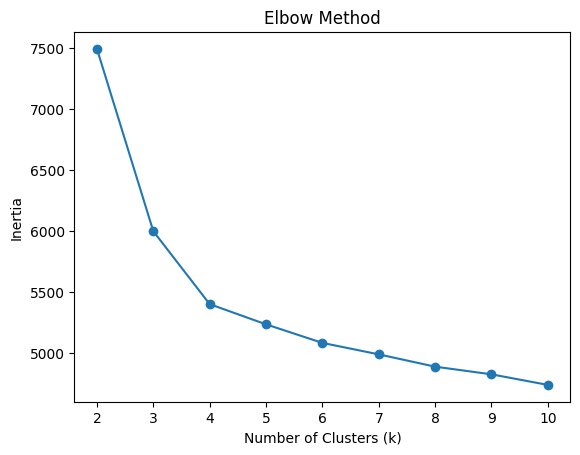

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

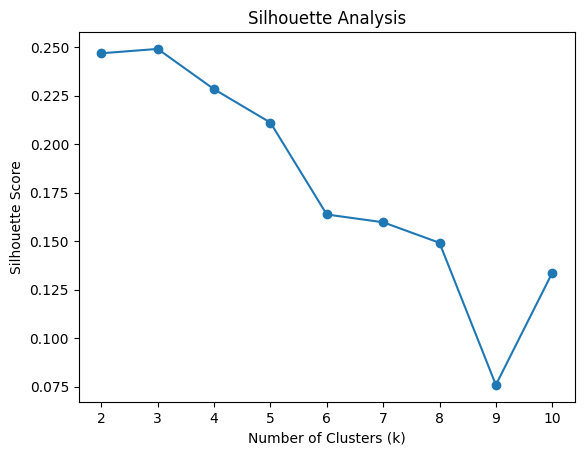

In [4]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()